# AI & ML Foundations - Module 2: Forms of Data
## Hands-on Lab: Features, Labels, Data Quality

**Instructions:** Run each cell in order. Read the comments and printed outputs carefully.
At the end, answer the reflection question in the final cell.

## Task 1: Structured vs. Unstructured Data
**Goal:** See the difference between a clean table (rows/columns) and raw pixel data.

STRUCTURED DATA EXAMPLE
Shape: (891, 15) (rows = records, columns = fields)

First 5 rows (notice the fixed schema: age, sex, fare, etc.):
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Column Names (The 'Schema') ---
['survived', 'pclass', 'sex', 'age', 'sibsp

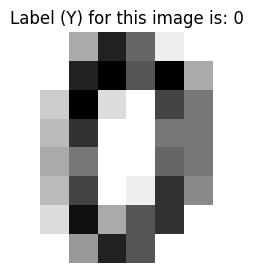


💡 Aha: Even though this image is a grid (structured in memory), we call it 'unstructured' because individual pixels don't have human-meaningful column names like 'Age' or 'Fare'. We need deep learning or feature extraction to turn this grid into useful inputs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. STRUCTURED DATA (The Titanic dataset) ---
print("="*60)
print("STRUCTURED DATA EXAMPLE")
print("="*60)

titanic = sns.load_dataset('titanic')
print(f"Shape: {titanic.shape} (rows = records, columns = fields)")
print("\nFirst 5 rows (notice the fixed schema: age, sex, fare, etc.):")
print(titanic.head())

print("\n--- Column Names (The 'Schema') ---")
print(titanic.columns.tolist())

# --- 2. UNSTRUCTURED DATA (A single grayscale digit image) ---
print("\n" + "="*60)
print("UNSTRUCTURED DATA EXAMPLE")
print("="*60)

from sklearn.datasets import load_digits

digits = load_digits()
single_image = digits.images[0]  # This is an 8x8 grid of pixel intensities

print(f"Type: {type(single_image)}")
print(f"Shape of raw data: {single_image.shape} (an 8x8 matrix)")
print("\nRaw pixel values (each number is a shade of gray, 0=white, 16=black):")
print(single_image)

# Visualize it
plt.figure(figsize=(3, 3))
plt.imshow(single_image, cmap='gray_r')
plt.title(f"Label (Y) for this image is: {digits.target[0]}")
plt.axis('off')
plt.show()

print("\n💡 Aha: Even though this image is a grid (structured in memory), we call it 'unstructured' because individual pixels don't have human-meaningful column names like 'Age' or 'Fare'. We need deep learning or feature extraction to turn this grid into useful inputs.")

## Task 2: The 4 V's – Volume & Veracity in Action
**Goal:** See how data size affects computation speed, and how bad values (outliers) ruin your distribution.

VOLUME: How size affects speed
Small (100 rows) mean: -0.0614 | Computed in: 0.000336 sec
Large (100k rows) mean: -0.0017 | Computed in: 0.000329 sec
⚠️ Larger volume = slower processing. This is why we sample data or use Big Data tools.

VERACITY: How outliers destroy the distribution
Clean Salary Mean: $50,239.99
Corrupted Salary Mean: $75,759.48
❌ A few bad values pulled the average up by 25,519.50!



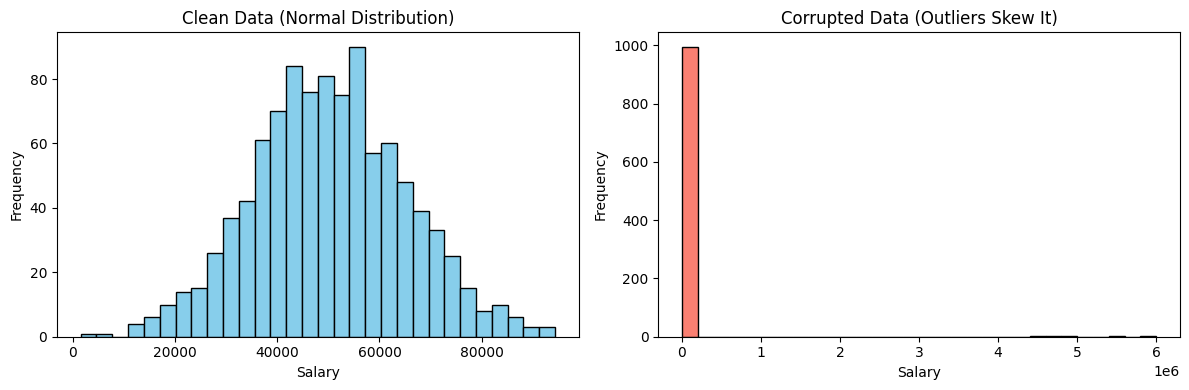

In [2]:
import time

print("="*60)
print("VOLUME: How size affects speed")
print("="*60)

# Small dataset vs Large dataset
small_data = np.random.randn(100, 1)
large_data = np.random.randn(100000, 1)  # 1000x larger

start = time.time()
mean_small = np.mean(small_data)
time_small = time.time() - start

start = time.time()
mean_large = np.mean(large_data)
time_large = time.time() - start

print(f"Small (100 rows) mean: {mean_small:.4f} | Computed in: {time_small:.6f} sec")
print(f"Large (100k rows) mean: {mean_large:.4f} | Computed in: {time_large:.6f} sec")
print(f"⚠️ Larger volume = slower processing. This is why we sample data or use Big Data tools.\n")

# --- Veracity: Injecting Outliers ---
print("="*60)
print("VERACITY: How outliers destroy the distribution")
print("="*60)

# Clean data
clean_salaries = np.random.normal(loc=50000, scale=15000, size=1000)

# Corrupted data (add 5 extreme outliers)
corrupted_salaries = clean_salaries.copy()
corrupted_salaries[0:5] = [5_000_000, 4_500_000, 6_000_000, 4_800_000, 5_500_000]  # 100x larger

print(f"Clean Salary Mean: ${np.mean(clean_salaries):,.2f}")
print(f"Corrupted Salary Mean: ${np.mean(corrupted_salaries):,.2f}")  # Dramatically skewed
print(f"❌ A few bad values pulled the average up by {np.mean(corrupted_salaries) - np.mean(clean_salaries):,.2f}!\n")

# Plot the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(clean_salaries, bins=30, color='skyblue', edgecolor='black')
ax1.set_title("Clean Data (Normal Distribution)")
ax1.set_xlabel("Salary")
ax1.set_ylabel("Frequency")

ax2.hist(corrupted_salaries, bins=30, color='salmon', edgecolor='black')
ax2.set_title("Corrupted Data (Outliers Skew It)")
ax2.set_xlabel("Salary")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Task 3: Features vs. Labels – It Depends on the Task
**Goal:** Understand that X and Y are not inherent to the dataset; they are defined by what you want to predict.

In [3]:
from sklearn.datasets import fetch_california_housing

# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame  # This gives us a Pandas DataFrame

print("California Housing Dataset (first 5 rows):")
print(df.head())
print(f"\nColumn names: {df.columns.tolist()}")

# --- Scenario 1: Predict House Price (MedHouseVal) ---
print("\n" + "="*60)
print("SCENARIO 1: Predict the house price (MedHouseVal)")
print("="*60)

X1 = df.drop(columns=['MedHouseVal'])  # All columns EXCEPT the target
y1 = df['MedHouseVal']                 # The target

print(f"Features (X) shape: {X1.shape}  (These are the inputs we know)")
print(f"Label (y) shape: {y1.shape}    (This is what we want to predict)")
print(f"Label column name: 'MedHouseVal'")

# --- Scenario 2: Predict the number of bedrooms (AveBedrms) ---
print("\n" + "="*60)
print("SCENARIO 2: Predict the average number of bedrooms (AveBedrms)")
print("="*60)

X2 = df.drop(columns=['AveBedrms'])   # Now we drop a DIFFERENT column
y2 = df['AveBedrms']                  # Now THIS is the target

print(f"Features (X) shape: {X2.shape}")
print(f"Label (y) shape: {y2.shape}")
print(f"Label column name: 'AveBedrms'")

print("\n💡 The exact same table can produce different X and Y depending on the business problem. Always define your Y first!")

California Housing Dataset (first 5 rows):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

SCENARIO 1: Predict the house price (MedHouseVal)
Features (X) shape: (20640, 8)  (These are the inputs we know)
Label (y) shape: (20640,)    (This is what we want to predict)
Label column name: 'MedHou

## Task 4: Handling Numerical Scale & Categorical Encoding
**Goal:** See why scaling matters for numerical features, and why you can't feed "Red" or "Blue" directly into a model.

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Create a synthetic dataset with mixed types
data = pd.DataFrame({
    'Age': [25, 30, 35, 40, 45],
    'Salary': [30000, 60000, 90000, 120000, 150000],  # Wide range (0-150k)
    'City': ['NYC', 'LA', 'NYC', 'CHI', 'LA']
})

print("Original Dataset:")
print(data)

# --- Part A: Numerical Scale (Age vs Salary) ---
print("\n" + "="*60)
print("PART A: Numerical Scale – The Danger of Different Ranges")
print("="*60)

print("Variance (spread) of Age:", np.var(data['Age']))
print("Variance (spread) of Salary:", np.var(data['Salary']))
print("⚠️ Salary has much higher variance. A model (like linear regression) would think Salary is 'more important' just because the numbers are bigger, NOT because it's more predictive!")

# Apply StandardScaler (z-score: mean=0, std=1)
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(data[['Age', 'Salary']])
scaled_df = pd.DataFrame(scaled_numerical, columns=['Age_scaled', 'Salary_scaled'])

print("\nAfter StandardScaler (both have mean=0, std=1):")
print(scaled_df)
print("✅ Now Age and Salary are on the same scale. The model won't be biased by magnitude.")

# --- Part B: Categorical Encoding (City) ---
print("\n" + "="*60)
print("PART B: Categorical Encoding – The Label vs One-Hot Trap")
print("="*60)

# LabelEncoder (Ordinal - gives arbitrary numbers)
le = LabelEncoder()
city_label_encoded = le.fit_transform(data['City'])

print("City column as strings:")
print(data['City'].tolist())
print("\nLabelEncoder output (assigns 0, 1, 2 arbitrarily):")
print(city_label_encoded)
print("⚠️ DANGER: The model sees CHI=0, LA=1, NYC=2. It thinks NYC > LA > CHI, which is meaningless (no ordinal relationship)!")

# OneHotEncoder (Correct for nominal categories)
ohe = OneHotEncoder(sparse_output=False)
city_onehot = ohe.fit_transform(data[['City']])
city_onehot_df = pd.DataFrame(city_onehot, columns=ohe.get_feature_names_out(['City']))

print("\nOneHotEncoder output (creates a binary column for EACH city):")
print(city_onehot_df)
print("✅ Each city gets its own column. No fake ordering. This is the right way for colors, cities, or genders.")

Original Dataset:
   Age  Salary City
0   25   30000  NYC
1   30   60000   LA
2   35   90000  NYC
3   40  120000  CHI
4   45  150000   LA

PART A: Numerical Scale – The Danger of Different Ranges
Variance (spread) of Age: 50.0
Variance (spread) of Salary: 1800000000.0
⚠️ Salary has much higher variance. A model (like linear regression) would think Salary is 'more important' just because the numbers are bigger, NOT because it's more predictive!

After StandardScaler (both have mean=0, std=1):
   Age_scaled  Salary_scaled
0   -1.414214      -1.414214
1   -0.707107      -0.707107
2    0.000000       0.000000
3    0.707107       0.707107
4    1.414214       1.414214
✅ Now Age and Salary are on the same scale. The model won't be biased by magnitude.

PART B: Categorical Encoding – The Label vs One-Hot Trap
City column as strings:
['NYC', 'LA', 'NYC', 'CHI', 'LA']

LabelEncoder output (assigns 0, 1, 2 arbitrarily):
[2 1 2 0 1]
⚠️ DANGER: The model sees CHI=0, LA=1, NYC=2. It thinks NYC > LA 

## Task 5: Data Leakage – The Cheat Code
**Goal:** Identify features that "leak" information from the future (or the label itself) and must be dropped.

In [5]:
print("="*60)
print("DATA LEAKAGE: The 'Price per SqFt' Trap")
print("="*60)

# Synthetic housing data
housing_data = pd.DataFrame({
    'House_ID': [1, 2, 3, 4, 5],
    'SqFt': [1500, 2000, 1200, 1800, 2500],
    'Neighborhood': ['A', 'B', 'A', 'C', 'B'],
    'Price_per_sqft': [300, 250, 310, 280, 240],  # <-- THIS IS THE LEAK!
    'Actual_Price': [450000, 500000, 372000, 504000, 600000]  # This is our Label Y
})

print("Our dataset:")
print(housing_data)

# Naively split into X and y
X_naive = housing_data.drop(columns=['Actual_Price'])
y = housing_data['Actual_Price']

print("\nNaively, we put everything except Actual_Price into X:")
print(f"Features (X): {X_naive.columns.tolist()}")

print("\n" + "!"*60)
print("❌ PROBLEM: 'Price_per_sqft' is calculated as Actual_Price / SqFt!")
print("If we know the price per sqft, we can just multiply by SqFt to get the price.")
print("This feature CONTAINS the label. It would be available at prediction time? NO.")
print("You wouldn't know the price per sqft before you predict the price.")
print("!"*60)

# The correct approach: Drop the leaked feature
X_correct = housing_data.drop(columns=['Actual_Price', 'Price_per_sqft'])

print("\n✅ CORRECT Features (dropping the leak):")
print(f"Features (X): {X_correct.columns.tolist()}")
print("\n💡 General Rule: If a feature logically depends on the label, or on information you won't have at prediction time, DROP IT IMMEDIATELY.")

DATA LEAKAGE: The 'Price per SqFt' Trap
Our dataset:
   House_ID  SqFt Neighborhood  Price_per_sqft  Actual_Price
0         1  1500            A             300        450000
1         2  2000            B             250        500000
2         3  1200            A             310        372000
3         4  1800            C             280        504000
4         5  2500            B             240        600000

Naively, we put everything except Actual_Price into X:
Features (X): ['House_ID', 'SqFt', 'Neighborhood', 'Price_per_sqft']

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
❌ PROBLEM: 'Price_per_sqft' is calculated as Actual_Price / SqFt!
If we know the price per sqft, we can just multiply by SqFt to get the price.
This feature CONTAINS the label. It would be available at prediction time? NO.
You wouldn't know the price per sqft before you predict the price.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

✅ CORRECT Features (dropping the leak):
Fe

## Task 6: Missing Data – Not All NaNs are Created Equal
**Goal:** Visualize missing patterns and understand that dropping rows can introduce bias.

Dataset with Missing Values (first 20 rows):
    Patient_ID  Gender   Age  Blood_Pressure
0            1    Male  49.0           127.0
1            2  Female  56.0           173.0
2            3    Male  66.0           178.0
3            4    Male  69.0           114.0
4            5    Male  78.0           107.0
5            6  Female   NaN           171.0
6            7    Male  21.0           155.0
7            8    Male  47.0           143.0
8            9    Male  54.0           124.0
9           10  Female  40.0           169.0
10          11    Male  56.0           150.0
11          12    Male  62.0             NaN
12          13    Male  32.0           122.0
13          14    Male  60.0             NaN
14          15  Female   NaN             NaN
15          16    Male  53.0           103.0
16          17  Female  30.0             NaN
17          18  Female  49.0           137.0
18          19  Female   NaN           109.0
19          20    Male  76.0             NaN

Generatin

<Figure size 1000x400 with 0 Axes>

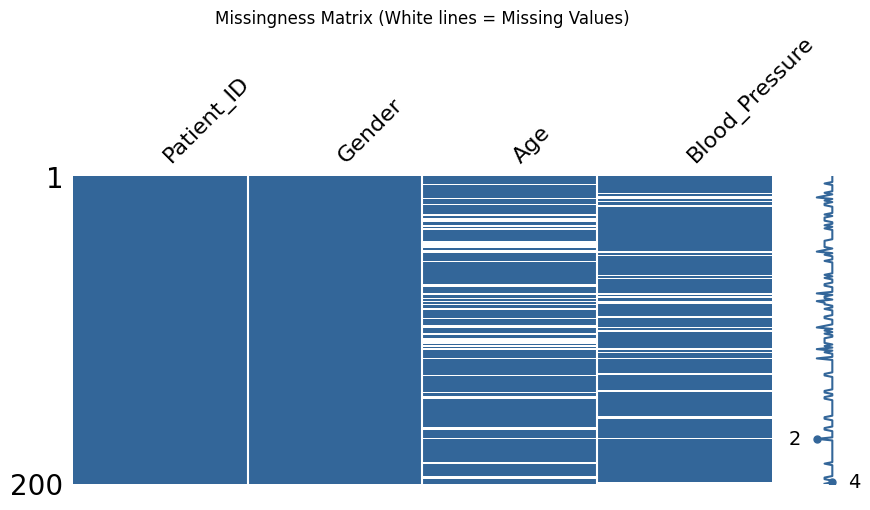


THE BIAS QUESTION
Total Females: 100 | Females missing Age: 45
Total Males: 100 | Males missing Age: 0

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
❌ If we simply 'drop all rows with missing Age', we will lose a huge chunk of Females.
The resulting dataset would be biased toward Males.
💡 Moral: Always investigate WHY data is missing before you decide how to handle it.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [6]:
# Create a dataset with missing values
np.random.seed(42)
n = 200
df_missing = pd.DataFrame({
    'Patient_ID': range(1, n+1),
    'Gender': np.random.choice(['Male', 'Female'], size=n),
    'Age': np.random.randint(18, 80, size=n),
    'Blood_Pressure': np.random.randint(90, 180, size=n)
})

# Introduce missingness:
# 1. MCAR (Missing Completely at Random): Random 10% nulls in Blood_Pressure
mcar_mask = np.random.random(n) < 0.1
df_missing.loc[mcar_mask, 'Blood_Pressure'] = np.nan

# 2. MAR (Missing at Random): Age is missing only for Females (systematic bias)
mar_mask = (df_missing['Gender'] == 'Female') & (np.random.random(n) < 0.4)
df_missing.loc[mar_mask, 'Age'] = np.nan

print("Dataset with Missing Values (first 20 rows):")
print(df_missing.head(20))

# --- Visualize Missingness ---
try:
    import missingno as msno
    print("\nGenerating missingness heatmap...")
    plt.figure(figsize=(10, 4))
    msno.matrix(df_missing, figsize=(10, 4), color=(0.2, 0.4, 0.6))
    plt.title("Missingness Matrix (White lines = Missing Values)")
    plt.show()
except ImportError:
    print("\n⚠️ 'missingno' not installed. Visualizing with a simple heatmap instead.")
    plt.figure(figsize=(8, 4))
    sns.heatmap(df_missing.isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title("Missing Values Heatmap (Yellow = Missing)")
    plt.show()

# --- The Bias Question ---
print("\n" + "="*60)
print("THE BIAS QUESTION")
print("="*60)

total_females = len(df_missing[df_missing['Gender'] == 'Female'])
total_males = len(df_missing[df_missing['Gender'] == 'Male'])
missing_age_females = df_missing[df_missing['Gender'] == 'Female']['Age'].isnull().sum()
missing_age_males = df_missing[df_missing['Gender'] == 'Male']['Age'].isnull().sum()

print(f"Total Females: {total_females} | Females missing Age: {missing_age_females}")
print(f"Total Males: {total_males} | Males missing Age: {missing_age_males}")

print("\n" + "!"*60)
print("❌ If we simply 'drop all rows with missing Age', we will lose a huge chunk of Females.")
print("The resulting dataset would be biased toward Males.")
print("💡 Moral: Always investigate WHY data is missing before you decide how to handle it.")
print("!"*60)